# 📊 EDA – 4 Models × 1 Dataset: find_segment

**Dataset**: `models/yolo/find_segment.v6i.yolov12` — cùng 1 dataset cho tất cả 4 model  
**Câu hỏi**: YOLO thuần (v12/v26) vs DocLayout-YOLO khi cùng finetune trên find_segment?

| | YOLOv12 (v1) | YOLOv12 (v2) | YOLOv26 | DocLayout-YOLO |
|---|---|---|---|---|
| Model | YOLOv12s | YOLOv12s | YOLO26s | DocLayout-YOLOv10m |
| Size | ~18 MB | ~18 MB | ~18 MB | ~153 MB |
| Pretrained | COCO | COCO | COCO | DocStructBench |
| Dataset | find_segment | find_segment | find_segment | find_segment |
| Test results | ✅ | ✅ | ✅ | ✅ (eval_results.xlsx) |

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})

# === PATHS ===
# Notebook runs from notebooks/ folder → ROOT is ..
ROOT = Path('..')

# Dataset (same for all 4 models)
DATASET = ROOT / 'models/yolo/find_segment.v6i.yolov12'

# Training result CSVs (YOLO models)
YOLO_RESULTS = {
    'YOLOv12 (v1)': ROOT / 'models/yolo/yolo12_train-results_v1/results.csv',
    'YOLOv12 (v2)': ROOT / 'models/yolo/yolo12_train_results_v2/results.csv',
    'YOLOv26':      ROOT / 'models/yolo/yolo26_train_results/results.csv',
}

# DocLayout — training log (val every 5 epoch)
DOCLAYOUT_LOG = ROOT / 'models/doclayout-yolo/doclayout-yolo-fintuine in dataset findsegment.md'

# DocLayout — test/eval results (eval_results.xlsx)
DOCLAYOUT_EVAL = ROOT / 'models/doclayout-yolo/doclayout-yolo_finetune_fingsegment_dataset/eval_results.xlsx'
DOCLAYOUT_EVAL_DIR = ROOT / 'models/doclayout-yolo/doclayout-yolo_finetune_fingsegment_dataset'

EXP_COLORS = {
    'YOLOv12 (v1)':  '#95a5a6',
    'YOLOv12 (v2)':  '#e67e22',
    'YOLOv26':       '#2980b9',
    'DocLayout-YOLO':'#e74c3c',
}
EXP_ORDER = ['YOLOv12 (v1)', 'YOLOv12 (v2)', 'YOLOv26', 'DocLayout-YOLO']

# ── Hardcoded TEST metrics from actual inference runs ──────────────────────
# YOLO models: evaluated with model.val(split='test', ...)
# DocLayout:   from doclayout-yolo_finetune_fingsegment_dataset/eval_results.xlsx
TEST_METRICS = {
    'YOLOv12 (v1)': {'mAP50':0.5762, 'mAP50-95':0.3535, 'P':0.8014, 'R':0.4630},
    'YOLOv12 (v2)': {'mAP50':0.7899, 'mAP50-95':0.5790, 'P':0.7476, 'R':0.7679},
    'YOLOv26':      {'mAP50':0.7561, 'mAP50-95':0.5410, 'P':0.8407, 'R':0.6843},
    'DocLayout-YOLO':{'mAP50':0.7520, 'mAP50-95':0.5614, 'P':0.8690, 'R':0.6759},
}

print('✅ Setup OK')
print(f'   Dataset path: {DATASET.resolve()}')
print(f'   DocLayout log: {DOCLAYOUT_LOG.exists()}')
print(f'   DocLayout eval: {DOCLAYOUT_EVAL.exists()}')

✅ Setup OK
   Dataset path: /home/hoai/user/resource/fipilot/backend/models/yolo/find_segment.v6i.yolov12
   DocLayout log: True
   DocLayout eval: True


---
## 1. Dataset Overview – find_segment

In [2]:
def read_labels(lbl_dir):
    lbl_dir = Path(lbl_dir)
    if not lbl_dir.exists():
        return pd.DataFrame(columns=['cls','cx','cy','w','h','img']), []
    records, per_img = [], []
    for f in sorted(lbl_dir.glob('*.txt')):
        lines = [l.strip() for l in f.read_text().splitlines() if l.strip()]
        per_img.append(len(lines))
        for l in lines:
            p = list(map(float, l.split()))
            records.append({'cls':int(p[0]),'cx':p[1],'cy':p[2],'w':p[3],'h':p[4],'img':f.stem})
    if not records:
        return pd.DataFrame(columns=['cls','cx','cy','w','h','img']), per_img
    return pd.DataFrame(records), per_img

stats, dfs, per_imgs = {}, {}, {}
for split in ['train', 'valid', 'test']:
    df, ppi = read_labels(DATASET / split / 'labels')
    n_imgs = len(list((DATASET / split / 'images').glob('*')))
    dfs[split] = df
    per_imgs[split] = ppi
    stats[split] = {
        'images': n_imgs, 'bbox': len(df),
        'avg/img': round(np.mean(ppi),2) if ppi else 0,
        'min/img': min(ppi) if ppi else 0,
        'max/img': max(ppi) if ppi else 0,
    }

print('=== find_segment Dataset Stats ===')
print(pd.DataFrame(stats).T.to_string())
print(f'\nTotal: {sum(s["images"] for s in stats.values())} imgs | {sum(s["bbox"] for s in stats.values())} bbox')

=== find_segment Dataset Stats ===
       images   bbox  avg/img  min/img  max/img
train   501.0  978.0     1.95      1.0     22.0
valid   118.0  252.0     2.14      1.0     13.0
test     58.0  108.0     1.86      1.0      8.0

Total: 677 imgs | 1338 bbox


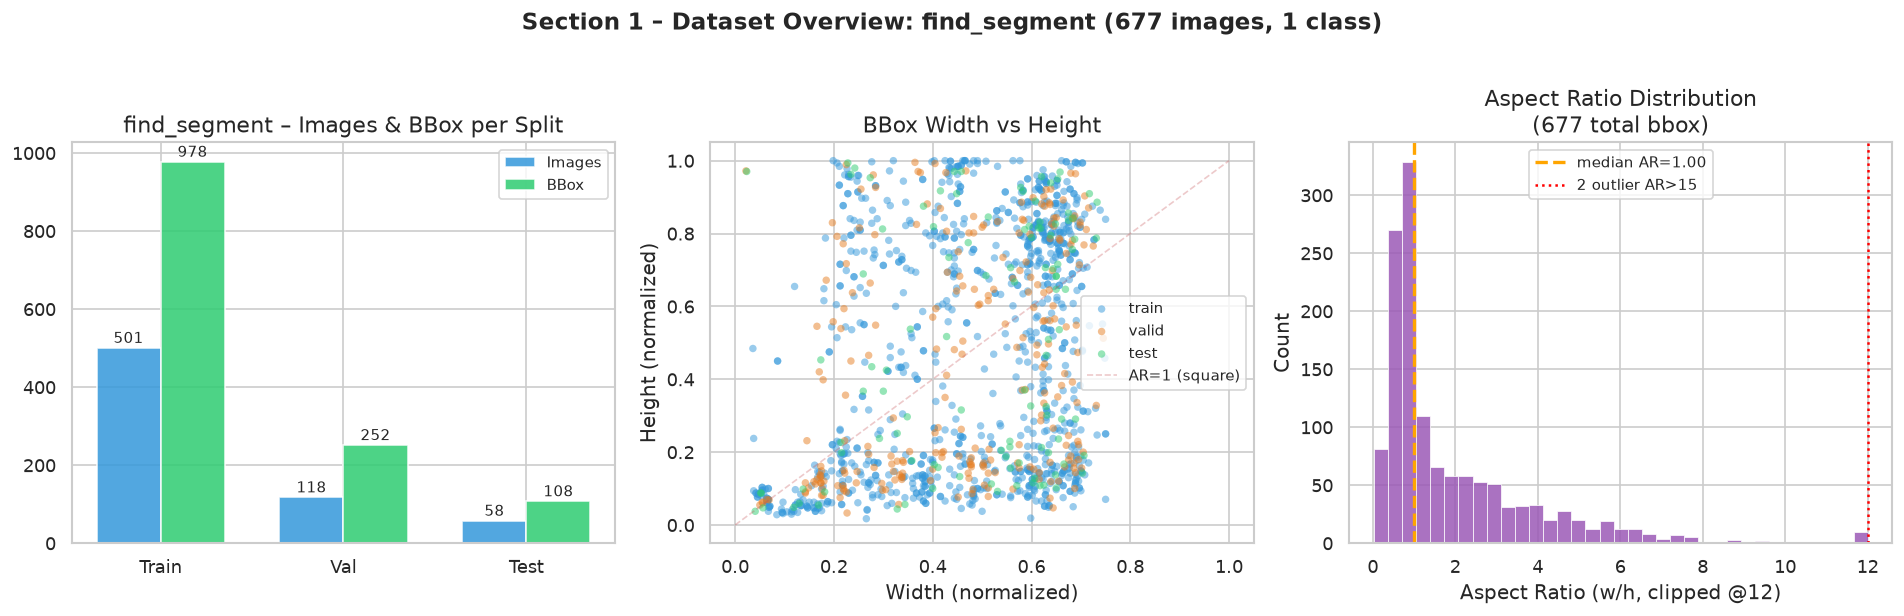

Saved: eda_s1_dataset.png


In [3]:
df_all = pd.concat(dfs.values(), ignore_index=True)
df_all['ar'] = df_all['w'] / df_all['h'].replace(0, np.nan)
df_all['area'] = df_all['w'] * df_all['h']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1.1: Images & bbox per split
ax = axes[0]
split_names = ['train', 'valid', 'test']
x = np.arange(3); w = 0.35
b1 = ax.bar(x-w/2, [stats[s]['images'] for s in split_names], w,
            label='Images', color='#3498db', alpha=0.85)
b2 = ax.bar(x+w/2, [stats[s]['bbox'] for s in split_names], w,
            label='BBox', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Train', 'Val', 'Test'])
ax.set_title('find_segment – Images & BBox per Split')
ax.legend(fontsize=9)
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

# 1.2: BBox width vs height
ax = axes[1]
split_colors = ['#3498db','#e67e22','#2ecc71']
for split, color in zip(split_names, split_colors):
    ax.scatter(dfs[split]['w'], dfs[split]['h'], alpha=0.5, s=20,
               color=color, label=split, edgecolors='none')
ax.plot([0,1],[0,1],'r--',alpha=0.3,lw=1,label='AR=1 (square)')
ax.set_xlabel('Width (normalized)'); ax.set_ylabel('Height (normalized)')
ax.set_title('BBox Width vs Height')
ax.legend(fontsize=9)

# 1.3: Aspect ratio histogram
ax = axes[2]
ar_clip = df_all['ar'].clip(0, 12)
outliers = df_all[df_all['ar'] > 15]
ax.hist(ar_clip, bins=35, color='#9b59b6', alpha=0.85, edgecolor='white', lw=0.5)
ax.axvline(df_all['ar'].median(), color='orange', lw=2, linestyle='--',
           label=f'median AR={df_all["ar"].median():.2f}')
ax.axvline(12, color='red', lw=1.5, linestyle=':', label=f'{len(outliers)} outlier AR>15')
ax.set_xlabel('Aspect Ratio (w/h, clipped @12)'); ax.set_ylabel('Count')
ax.set_title(f'Aspect Ratio Distribution\n(677 total bbox)')
ax.legend(fontsize=9)

plt.suptitle('Section 1 – Dataset Overview: find_segment (677 images, 1 class)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_s1_dataset.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_s1_dataset.png')

Outlier bbox (AR > 15): 2 bbox trong 2 ảnh
                                                                                                              img       w       h       ar
766  QA_Engineer_candidate_trinh-hoang-nguyen-ngoc-phuong-10279795_page_1_png.rf.01022d32a87058ba4ab7e4dab07539ba  0.5984  0.0188  31.9167
910                           a0a901e9-08c3-465d-a06c-f012654b3db1_page_6_png.rf.84835126de2c1ed9a8430d21202ef756  0.2656  0.0172  15.4545


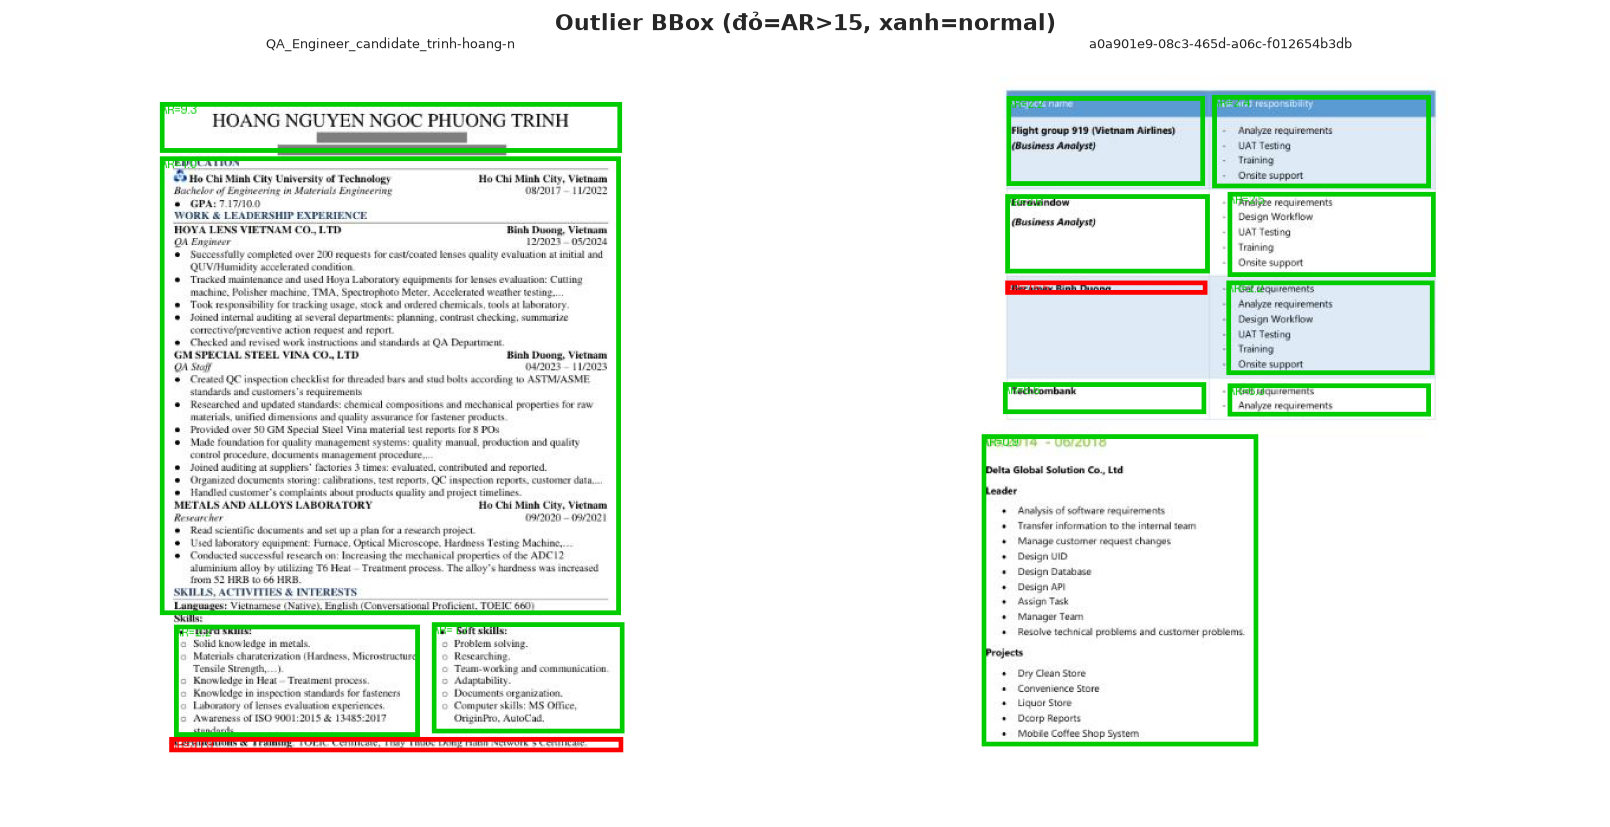

Saved: eda_s1_outliers.png


In [4]:
# Outlier visualization on images
from PIL import Image, ImageDraw

outlier_imgs = df_all[df_all['ar'] > 15]['img'].unique()
print(f'Outlier bbox (AR > 15): {len(df_all[df_all["ar"]>15])} bbox trong {len(outlier_imgs)} ảnh')
print(df_all[df_all['ar']>15][['img','w','h','ar']].round(4).to_string())

n = len(outlier_imgs)
if n > 0:
    fig, axes = plt.subplots(1, max(n, 1), figsize=(7*max(n,1), 7))
    if n == 1: axes = [axes]
    for ax, img_stem in zip(axes, outlier_imgs):
        img_path = None
        for split in ['train','valid','test']:
            for ext in ['.jpg','.jpeg','.png']:
                p = DATASET / split / 'images' / (img_stem + ext)
                if p.exists(): img_path = p; break
            if img_path: break
        if not img_path: ax.text(0.5,0.5,'Not found',ha='center',transform=ax.transAxes); continue
        img = Image.open(img_path); W, H = img.size
        draw = ImageDraw.Draw(img)
        for split in ['train','valid','test']:
            rows = dfs[split][dfs[split]['img']==img_stem]
            for _, r in rows.iterrows():
                ar_v = r['w']/r['h'] if r['h']>0 else 999
                color = 'red' if ar_v > 15 else '#00cc00'
                x1 = int((r['cx']-r['w']/2)*W); y1 = int((r['cy']-r['h']/2)*H)
                x2 = int((r['cx']+r['w']/2)*W); y2 = int((r['cy']+r['h']/2)*H)
                draw.rectangle([x1,y1,x2,y2], outline=color, width=4)
                draw.text((max(x1,2), max(y1,2)), f'AR={ar_v:.1f}', fill=color)
        ax.imshow(img); ax.set_title(f'{img_stem[:35]}', fontsize=8); ax.axis('off')
    plt.suptitle('Outlier BBox (đỏ=AR>15, xanh=normal)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_s1_outliers.png', bbox_inches='tight', dpi=100)
    plt.show()
    print('Saved: eda_s1_outliers.png')
else:
    print('No outlier images found')

---
## 2. Training Curves – 4 Models × 1 Dataset

In [5]:
# Load YOLO CSVs
yolo_dfs = {}
for name, path in YOLO_RESULTS.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    yolo_dfs[name] = df

# Parse DocLayout training log
log_text = DOCLAYOUT_LOG.read_text()
pat = re.compile(
    r'(\d+)/100[^\n]*\n.*?'
    r'all\s+118\s+250\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)',
    re.DOTALL
)
doc_val_rows = [{
    'epoch':int(m.group(1)),
    'P':float(m.group(2)), 'R':float(m.group(3)),
    'mAP50':float(m.group(4)), 'mAP50-95':float(m.group(5))
} for m in pat.finditer(log_text)]
doc_val_df = pd.DataFrame(doc_val_rows)

# Best val metrics per model
val_metrics = {}
for name, df in yolo_dfs.items():
    c50 = [c for c in df.columns if 'mAP50(B)' in c][0]
    c95 = [c for c in df.columns if 'mAP50-95' in c][0]
    pc  = [c for c in df.columns if 'precision' in c.lower()][0]
    rc  = [c for c in df.columns if 'recall' in c.lower()][0]
    bi  = df[c50].idxmax()
    val_metrics[name] = {
        'best_epoch': int(df.loc[bi,'epoch']),
        'total_epochs': len(df),
        'mAP50': df.loc[bi,c50],
        'mAP50-95': df.loc[bi,c95],
        'P': df.loc[bi,pc],
        'R': df.loc[bi,rc],
    }

best_doc = doc_val_df.loc[doc_val_df['mAP50'].idxmax()]
val_metrics['DocLayout-YOLO'] = {
    'best_epoch': int(best_doc['epoch']),
    'total_epochs': 54,
    'mAP50': best_doc['mAP50'],
    'mAP50-95': best_doc['mAP50-95'],
    'P': best_doc['P'],
    'R': best_doc['R'],
}

print('=== Best VAL Metrics ===')  
for name in EXP_ORDER:
    m = val_metrics[name]
    print(f"  {name:<20}: ep{m['best_epoch']:3d}/{m['total_epochs']} | mAP50={m['mAP50']:.4f} | mAP50-95={m['mAP50-95']:.4f} | P={m['P']:.4f} | R={m['R']:.4f}")

print()
print('=== TEST Metrics (actual inference on test split) ===')
for name in EXP_ORDER:
    m = TEST_METRICS[name]
    print(f"  {name:<20}: mAP50={m['mAP50']:.4f} | mAP50-95={m['mAP50-95']:.4f} | P={m['P']:.4f} | R={m['R']:.4f}")

=== Best VAL Metrics ===
  YOLOv12 (v1)        : ep 98/100 | mAP50=0.7530 | mAP50-95=0.5414 | P=0.6549 | R=0.7198
  YOLOv12 (v2)        : ep 91/100 | mAP50=0.8677 | mAP50-95=0.6295 | P=0.8088 | R=0.8122
  YOLOv26             : ep 97/100 | mAP50=0.8908 | mAP50-95=0.6717 | P=0.8793 | R=0.8082
  DocLayout-YOLO      : ep 36/54 | mAP50=0.8960 | mAP50-95=0.6580 | P=0.9060 | R=0.8120

=== TEST Metrics (actual inference on test split) ===
  YOLOv12 (v1)        : mAP50=0.5762 | mAP50-95=0.3535 | P=0.8014 | R=0.4630
  YOLOv12 (v2)        : mAP50=0.7899 | mAP50-95=0.5790 | P=0.7476 | R=0.7679
  YOLOv26             : mAP50=0.7561 | mAP50-95=0.5410 | P=0.8407 | R=0.6843
  DocLayout-YOLO      : mAP50=0.7520 | mAP50-95=0.5614 | P=0.8690 | R=0.6759


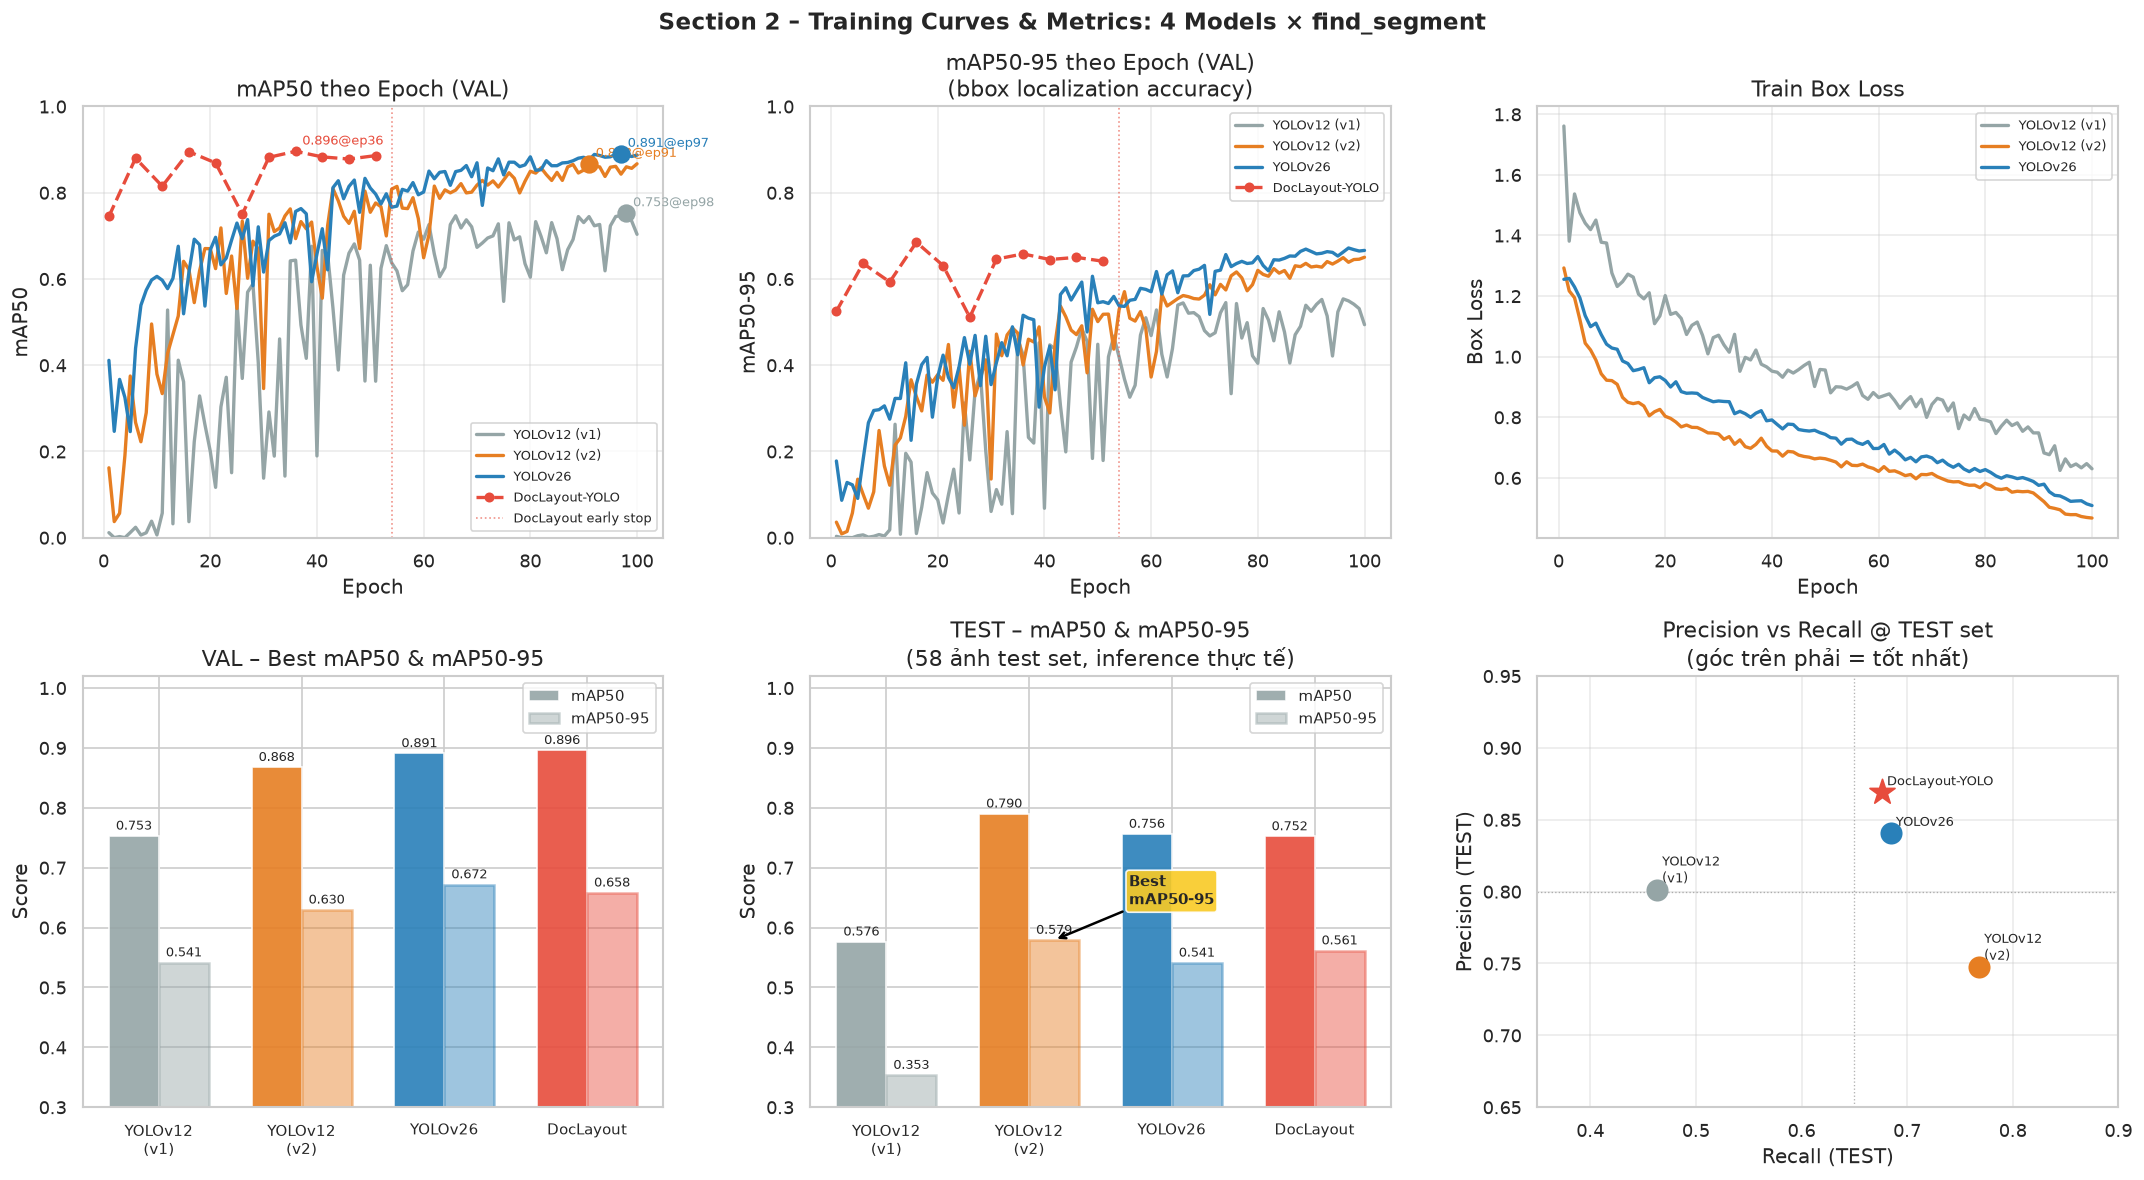

Saved: eda_s2_training.png


In [6]:
def get_col(df, key, excl=None):
    cols = [c for c in df.columns if key in c]
    if excl: cols = [c for c in cols if excl not in c]
    return cols[0] if cols else None

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 2.1: mAP50 theo epoch ────────────────────────────────────────────────
ax = axes[0,0]
for name, df in yolo_dfs.items():
    col = get_col(df,'mAP50(B)')
    ax.plot(df['epoch'], df[col], color=EXP_COLORS[name], label=name, lw=2)
    bi = df[col].idxmax()
    ax.scatter(df.loc[bi,'epoch'], df.loc[bi,col], color=EXP_COLORS[name], s=100, zorder=5)
    ax.annotate(f"{df.loc[bi,col]:.3f}@ep{int(df.loc[bi,'epoch'])}",
                xy=(df.loc[bi,'epoch'], df.loc[bi,col]),
                xytext=(4,4), textcoords='offset points', fontsize=8, color=EXP_COLORS[name])
# DocLayout checkpoint
ax.plot(doc_val_df['epoch'], doc_val_df['mAP50'],
        color=EXP_COLORS['DocLayout-YOLO'], label='DocLayout-YOLO',
        lw=2, linestyle='--', marker='o', markersize=5)
bi_doc = doc_val_df['mAP50'].idxmax()
ax.annotate(f"{doc_val_df.loc[bi_doc,'mAP50']:.3f}@ep{int(doc_val_df.loc[bi_doc,'epoch'])}",
            xy=(doc_val_df.loc[bi_doc,'epoch'], doc_val_df.loc[bi_doc,'mAP50']),
            xytext=(4,4), textcoords='offset points', fontsize=8, color=EXP_COLORS['DocLayout-YOLO'])
ax.axvline(54, color='#e74c3c', lw=1, linestyle=':', alpha=0.6, label='DocLayout early stop')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP50')
ax.set_title('mAP50 theo Epoch (VAL)'); ax.legend(fontsize=8); ax.set_ylim(0,1.0); ax.grid(alpha=0.4)

# ── 2.2: mAP50-95 theo epoch ─────────────────────────────────────────────
ax = axes[0,1]
for name, df in yolo_dfs.items():
    col = get_col(df,'mAP50-95')
    ax.plot(df['epoch'], df[col], color=EXP_COLORS[name], label=name, lw=2)
ax.plot(doc_val_df['epoch'], doc_val_df['mAP50-95'],
        color=EXP_COLORS['DocLayout-YOLO'], label='DocLayout-YOLO',
        lw=2, linestyle='--', marker='o', markersize=5)
ax.axvline(54, color='#e74c3c', lw=1, linestyle=':', alpha=0.6)
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP50-95')
ax.set_title('mAP50-95 theo Epoch (VAL)\n(bbox localization accuracy)'); ax.legend(fontsize=8); ax.set_ylim(0,1.0); ax.grid(alpha=0.4)

# ── 2.3: Box loss ─────────────────────────────────────────────────────────
ax = axes[0,2]
for name, df in yolo_dfs.items():
    col = get_col(df,'box_loss') or get_col(df,'box','val')
    if col: ax.plot(df['epoch'], df[col], color=EXP_COLORS[name], label=name, lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Box Loss'); ax.set_title('Train Box Loss'); ax.legend(fontsize=8); ax.grid(alpha=0.4)

# ── 2.4: VAL mAP50 bar comparison ────────────────────────────────────────
ax = axes[1,0]
colors4 = [EXP_COLORS[n] for n in EXP_ORDER]
labels4 = ['YOLOv12\n(v1)', 'YOLOv12\n(v2)', 'YOLOv26', 'DocLayout']
val_m50  = [val_metrics[n]['mAP50']    for n in EXP_ORDER]
val_m95  = [val_metrics[n]['mAP50-95'] for n in EXP_ORDER]
x = np.arange(4); wb = 0.35
b1 = ax.bar(x-wb/2, val_m50, wb, label='mAP50',    color=colors4, alpha=0.9)
b2 = ax.bar(x+wb/2, val_m95, wb, label='mAP50-95', color=colors4, alpha=0.45,
            edgecolor=colors4, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(labels4, fontsize=9)
ax.set_ylim(0.3, 1.02); ax.set_ylabel('Score'); ax.legend(fontsize=9)
ax.set_title('VAL – Best mAP50 & mAP50-95')
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ── 2.5: TEST mAP50 bar comparison ───────────────────────────────────────
ax = axes[1,1]
test_m50 = [TEST_METRICS[n]['mAP50']    for n in EXP_ORDER]
test_m95 = [TEST_METRICS[n]['mAP50-95'] for n in EXP_ORDER]
b1 = ax.bar(x-wb/2, test_m50, wb, label='mAP50',    color=colors4, alpha=0.9)
b2 = ax.bar(x+wb/2, test_m95, wb, label='mAP50-95', color=colors4, alpha=0.45,
            edgecolor=colors4, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(labels4, fontsize=9)
ax.set_ylim(0.3, 1.02); ax.set_ylabel('Score'); ax.legend(fontsize=9)
ax.set_title('TEST – mAP50 & mAP50-95\n(58 ảnh test set, inference thực tế)')
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
# Best model label
best_idx = np.argmax(test_m95)
ax.annotate('Best\nmAP50-95', xy=(best_idx+wb/2, test_m95[best_idx]),
            xytext=(best_idx+0.7, test_m95[best_idx]+0.06),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='#f9ca24', alpha=0.9))

# ── 2.6: Precision vs Recall (TEST) ──────────────────────────────────────
ax = axes[1,2]
for name in EXP_ORDER:
    m = TEST_METRICS[name]
    mk = '*' if name == 'DocLayout-YOLO' else 'o'
    sz = 250 if name == 'DocLayout-YOLO' else 150
    ax.scatter(m['R'], m['P'], s=sz, color=EXP_COLORS[name], zorder=5, marker=mk)
    ax.text(m['R']+0.005, m['P']+0.005, name.replace(' (',  '\n('), fontsize=8)
ax.set_xlabel('Recall (TEST)'); ax.set_ylabel('Precision (TEST)')
ax.set_title('Precision vs Recall @ TEST set\n(góc trên phải = tốt nhất)')
ax.set_xlim(0.35, 0.9); ax.set_ylim(0.65, 0.95)
ax.axhline(0.80, color='gray', lw=0.8, linestyle=':', alpha=0.6)
ax.axvline(0.65, color='gray', lw=0.8, linestyle=':', alpha=0.6)
ax.grid(alpha=0.4)

plt.suptitle('Section 2 – Training Curves & Metrics: 4 Models × find_segment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_s2_training.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_s2_training.png')

---
## 3. Val vs Test Gap Analysis

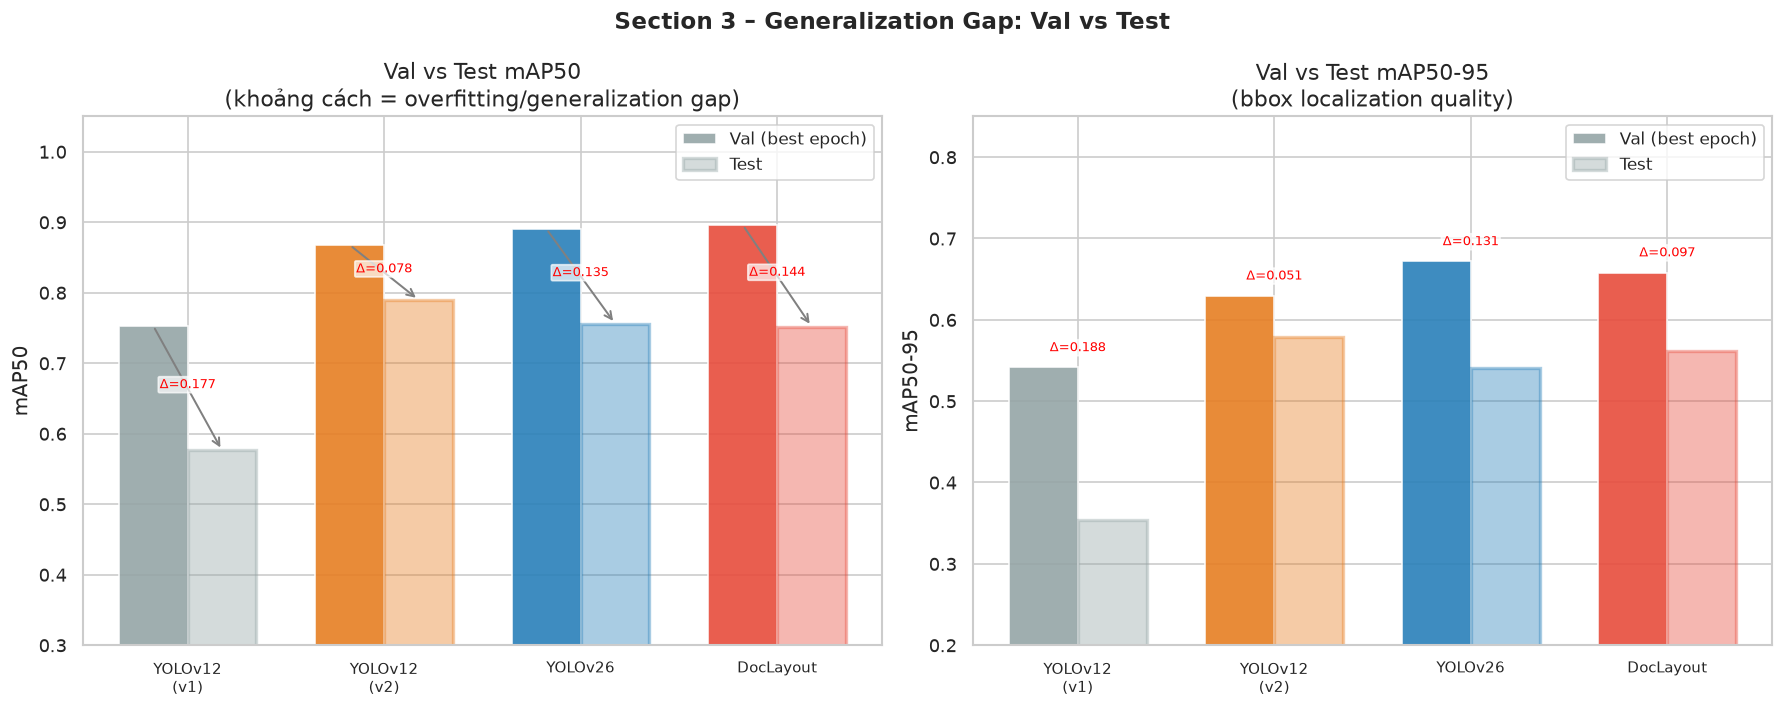

Saved: eda_s3_gap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 3.1: Val vs Test mAP50 – gap ─────────────────────────────────────────
ax = axes[0]
xp = np.arange(4); wb = 0.35
val_50 = [val_metrics[n]['mAP50'] for n in EXP_ORDER]
test_50 = [TEST_METRICS[n]['mAP50'] for n in EXP_ORDER]
b1 = ax.bar(xp-wb/2, val_50,  wb, label='Val (best epoch)', color=colors4, alpha=0.9)
b2 = ax.bar(xp+wb/2, test_50, wb, label='Test',             color=colors4, alpha=0.40,
            edgecolor=colors4, linewidth=2)
ax.set_xticks(xp); ax.set_xticklabels(labels4, fontsize=9)
ax.set_ylim(0.3, 1.05); ax.set_ylabel('mAP50'); ax.legend(fontsize=10)
ax.set_title('Val vs Test mAP50\n(khoảng cách = overfitting/generalization gap)')
# Gap arrows
for i, (v, t) in enumerate(zip(val_50, test_50)):
    gap = v - t
    ax.annotate('', xy=(xp[i]+wb/2, t), xytext=(xp[i]-wb/2, v),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    ax.text(xp[i], (v+t)/2, f'Δ={gap:.3f}', ha='center', fontsize=8,
            color='red' if gap > 0.05 else 'green',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))

# ── 3.2: Val vs Test mAP50-95 – gap ──────────────────────────────────────
ax = axes[1]
val_95  = [val_metrics[n]['mAP50-95']  for n in EXP_ORDER]
test_95 = [TEST_METRICS[n]['mAP50-95'] for n in EXP_ORDER]
b1 = ax.bar(xp-wb/2, val_95,  wb, label='Val (best epoch)', color=colors4, alpha=0.9)
b2 = ax.bar(xp+wb/2, test_95, wb, label='Test',             color=colors4, alpha=0.40,
            edgecolor=colors4, linewidth=2)
ax.set_xticks(xp); ax.set_xticklabels(labels4, fontsize=9)
ax.set_ylim(0.2, 0.85); ax.set_ylabel('mAP50-95'); ax.legend(fontsize=10)
ax.set_title('Val vs Test mAP50-95\n(bbox localization quality)')
for i, (v, t) in enumerate(zip(val_95, test_95)):
    gap = v - t
    ax.text(xp[i], max(v,t)+0.02, f'Δ={gap:.3f}', ha='center', fontsize=8,
            color='red' if gap > 0.05 else 'green',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))

plt.suptitle('Section 3 – Generalization Gap: Val vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_s3_gap.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_s3_gap.png')

---
## 4. DocLayout-YOLO – Eval Visualizations

Found 6 batch images in DocLayout eval dir


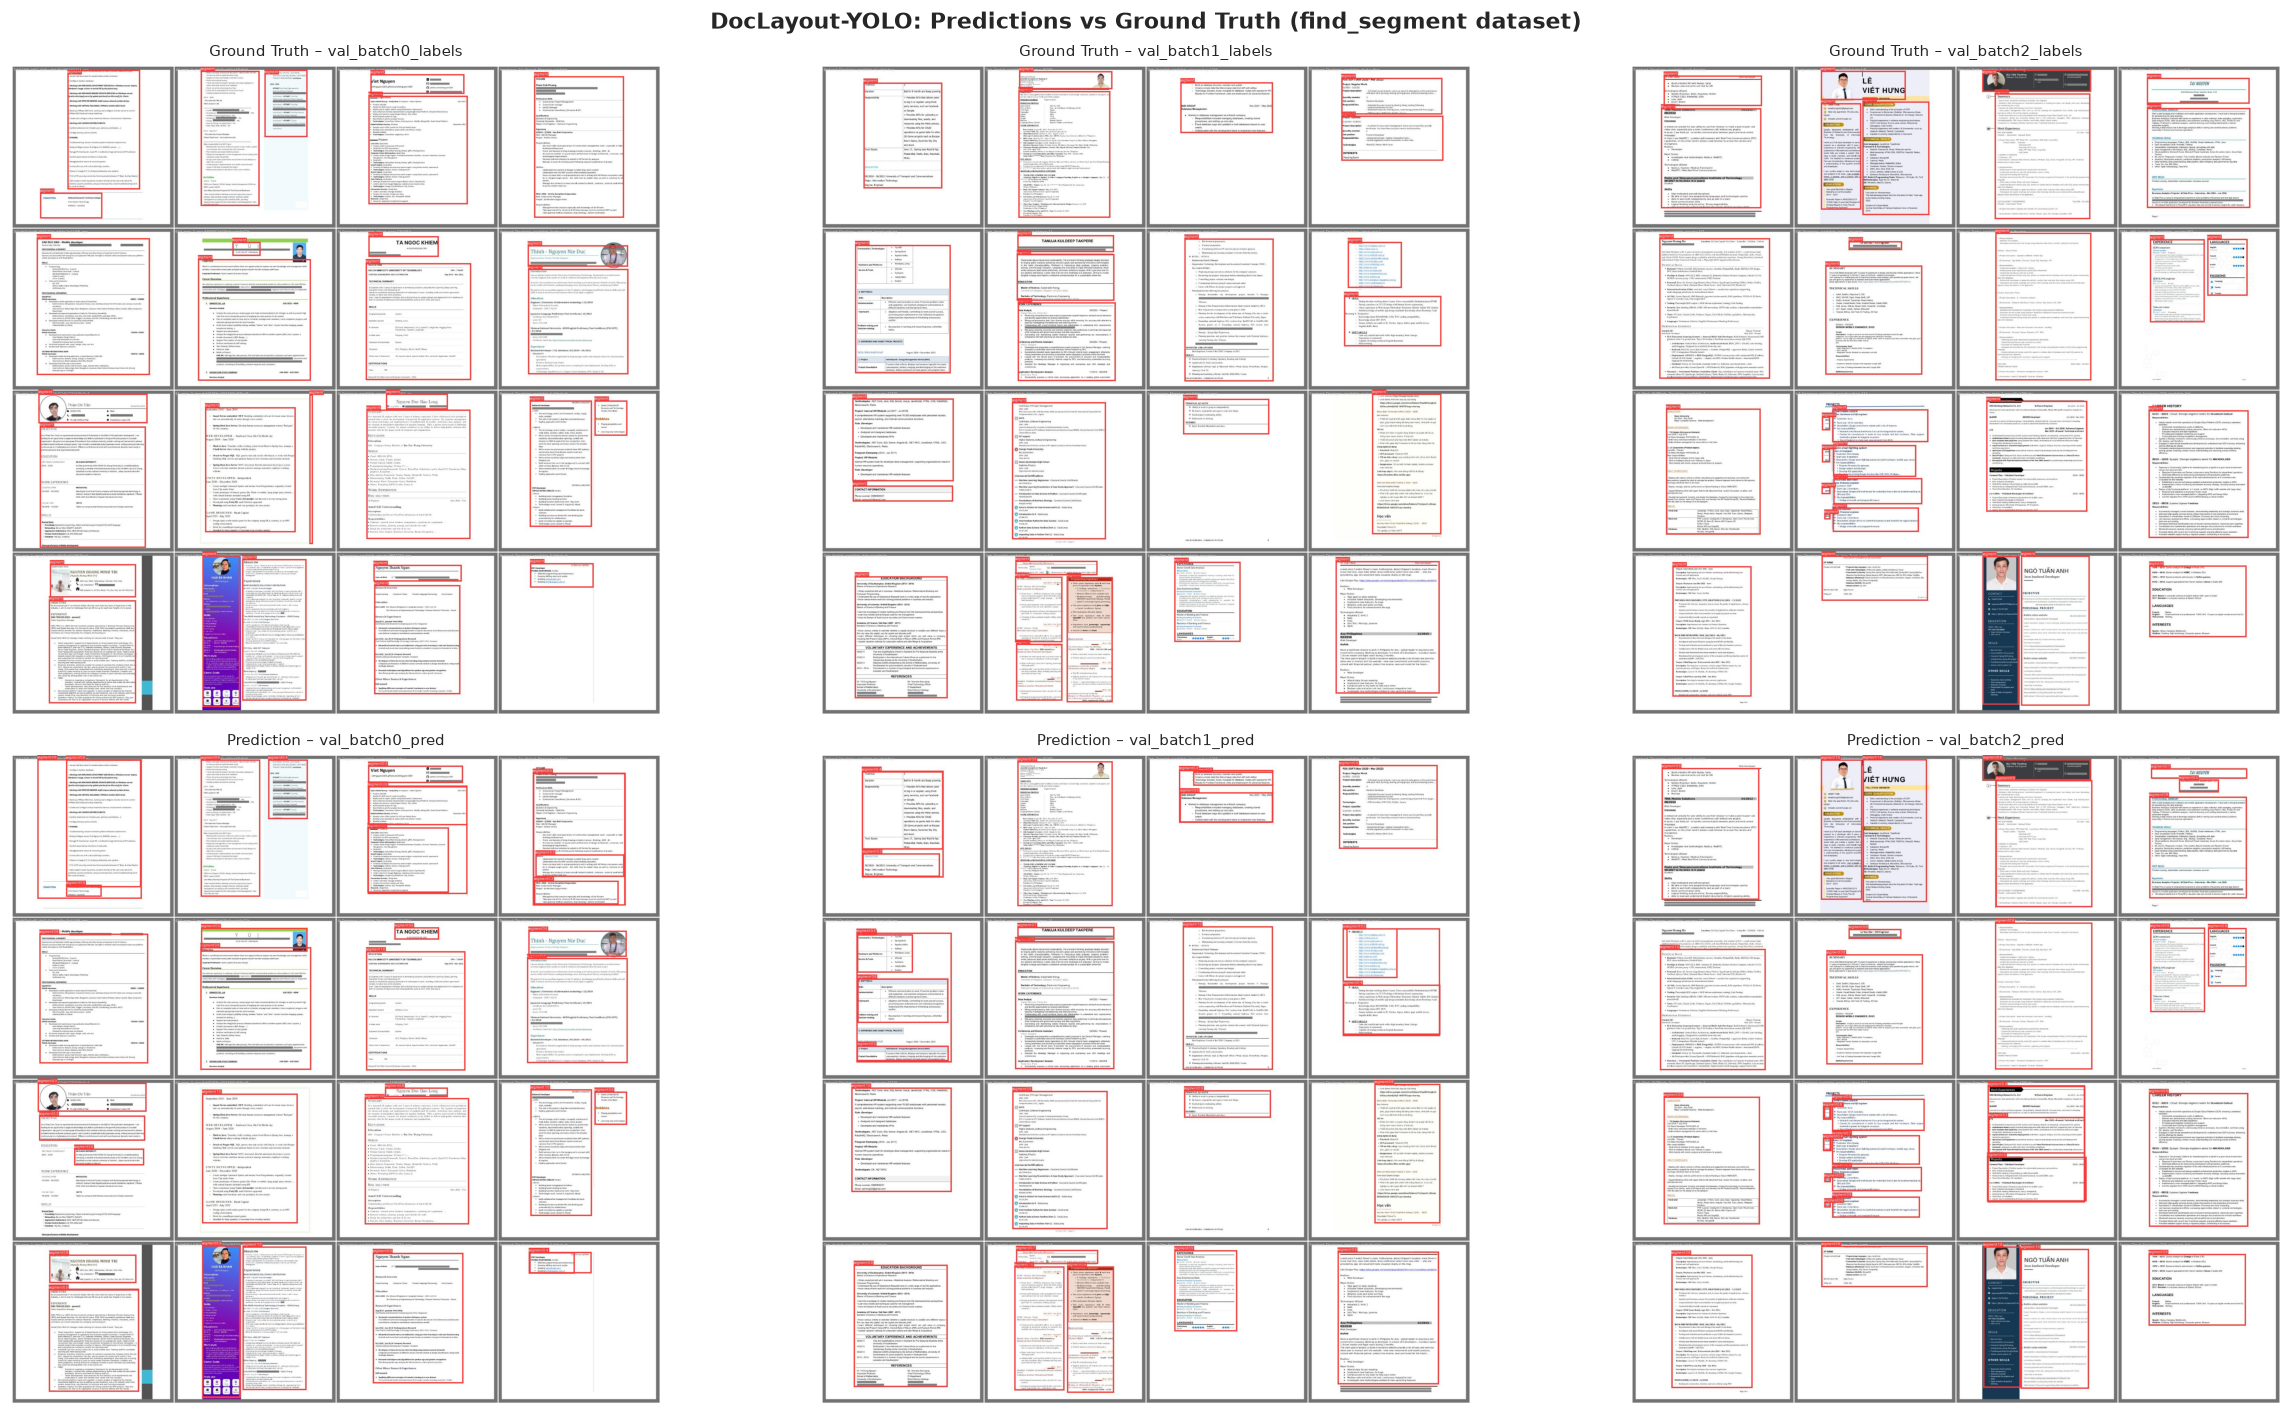

Saved: eda_s4_doclayout_pred.png


In [8]:
from PIL import Image

img_files = sorted(DOCLAYOUT_EVAL_DIR.glob('*.jpg')) + sorted(DOCLAYOUT_EVAL_DIR.glob('*.png'))
batch_files = [f for f in img_files if 'batch' in f.name]
print(f'Found {len(batch_files)} batch images in DocLayout eval dir')

# Show prediction images
pred_files = [f for f in batch_files if 'pred' in f.name][:3]
lbl_files  = [f for f in batch_files if 'labels' in f.name][:3]

if pred_files:
    n = len(pred_files)
    fig, axes = plt.subplots(2, n, figsize=(7*n, 12))
    if n == 1: axes = axes.reshape(2, 1)
    for i, (pf, lf) in enumerate(zip(pred_files, lbl_files)):
        axes[0,i].imshow(Image.open(lf))
        axes[0,i].set_title(f'Ground Truth – {lf.stem}', fontsize=9); axes[0,i].axis('off')
        axes[1,i].imshow(Image.open(pf))
        axes[1,i].set_title(f'Prediction – {pf.stem}', fontsize=9); axes[1,i].axis('off')
    plt.suptitle('DocLayout-YOLO: Predictions vs Ground Truth (find_segment dataset)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_s4_doclayout_pred.png', bbox_inches='tight', dpi=100)
    plt.show()
    print('Saved: eda_s4_doclayout_pred.png')
else:
    print('No prediction images found')

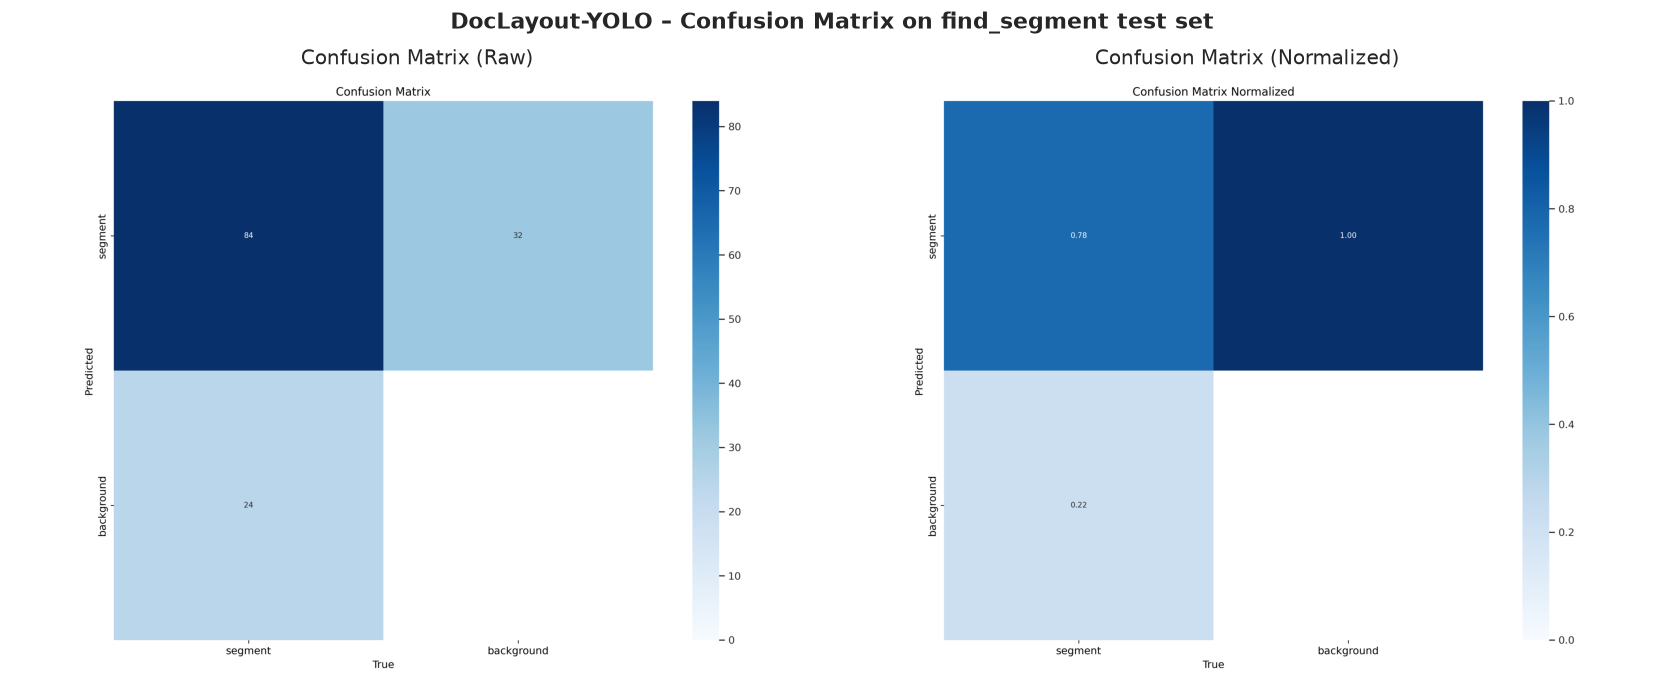

Saved: eda_s4_confusion.png


In [9]:
# Confusion matrices
conf_norm = DOCLAYOUT_EVAL_DIR / 'confusion_matrix_normalized.png'
conf_raw  = DOCLAYOUT_EVAL_DIR / 'confusion_matrix.png'

if conf_norm.exists() and conf_raw.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(Image.open(conf_raw));  axes[0].axis('off'); axes[0].set_title('Confusion Matrix (Raw)', fontsize=12)
    axes[1].imshow(Image.open(conf_norm)); axes[1].axis('off'); axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12)
    plt.suptitle('DocLayout-YOLO – Confusion Matrix on find_segment test set',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_s4_confusion.png', bbox_inches='tight', dpi=100)
    plt.show()
    print('Saved: eda_s4_confusion.png')

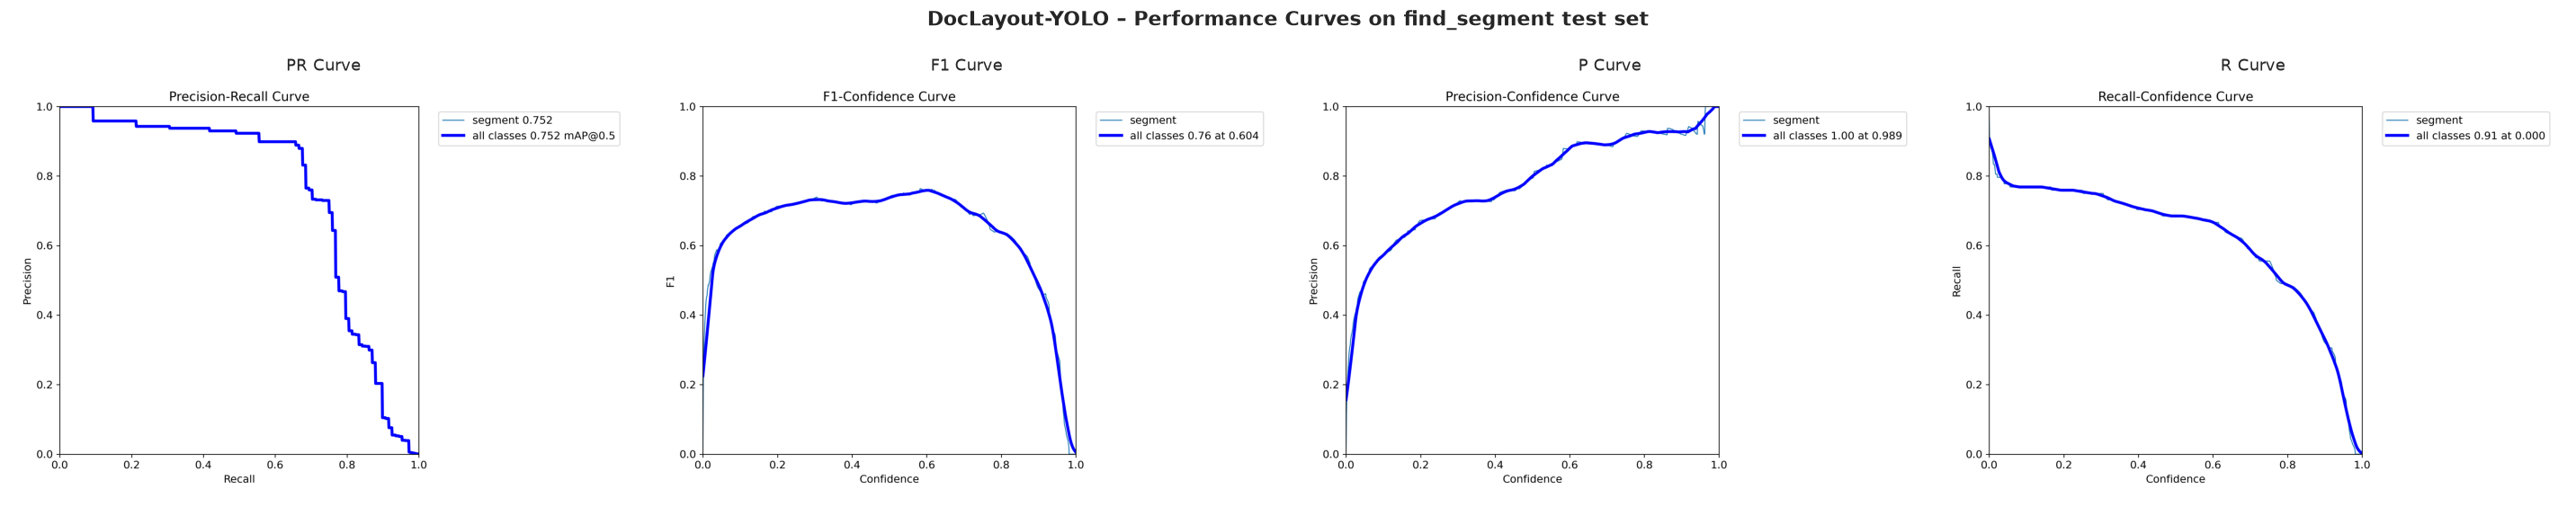

Saved: eda_s4_curves.png


In [10]:
# PR, F1, P, R curves
curve_files = {
    'PR Curve':  DOCLAYOUT_EVAL_DIR / 'PR_curve.png',
    'F1 Curve':  DOCLAYOUT_EVAL_DIR / 'F1_curve.png',
    'P Curve':   DOCLAYOUT_EVAL_DIR / 'P_curve.png',
    'R Curve':   DOCLAYOUT_EVAL_DIR / 'R_curve.png',
}
existing = [(name, path) for name, path in curve_files.items() if path.exists()]
if existing:
    fig, axes = plt.subplots(1, len(existing), figsize=(6*len(existing), 5))
    if len(existing) == 1: axes = [axes]
    for ax, (name, path) in zip(axes, existing):
        ax.imshow(Image.open(path)); ax.axis('off'); ax.set_title(name, fontsize=11)
    plt.suptitle('DocLayout-YOLO – Performance Curves on find_segment test set',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_s4_curves.png', bbox_inches='tight', dpi=100)
    plt.show()
    print('Saved: eda_s4_curves.png')

---
## 5. Final Summary – 4 Model Comparison

/tmp/ipykernel_68136/1429762063.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_s5_summary.png', bbox_inches='tight', dpi=120)
/home/hoai/user/resource/fipilot/backend/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


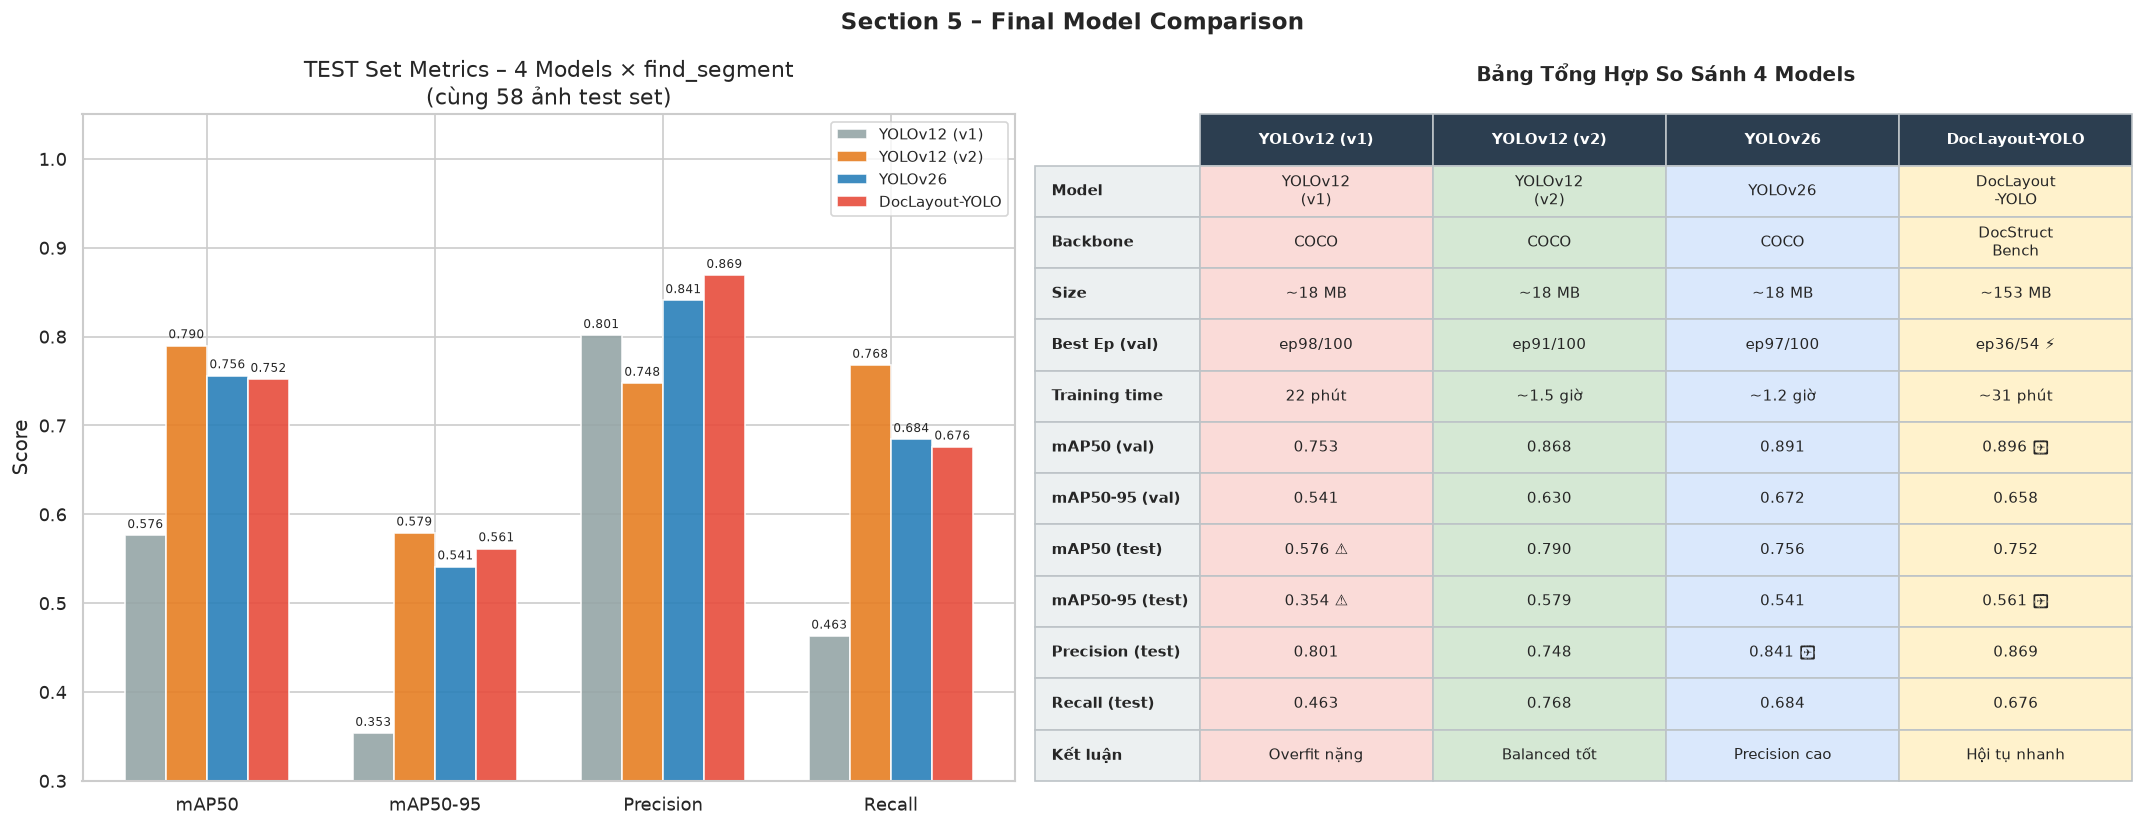

Saved: eda_s5_summary.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── 5.1: Grouped bar – all 4 TEST metrics ────────────────────────────────
ax = axes[0]
metrics_list = ['mAP50', 'mAP50-95', 'P', 'R']
metric_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
n_metrics = len(metrics_list)
n_models  = len(EXP_ORDER)
xpos = np.arange(n_metrics)
width = 0.18

for i, name in enumerate(EXP_ORDER):
    vals = [TEST_METRICS[name][m] for m in metrics_list]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(xpos + offset, vals, width, label=name,
                  color=EXP_COLORS[name], alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(xpos); ax.set_xticklabels(metric_labels)
ax.set_ylim(0.3, 1.05); ax.set_ylabel('Score')
ax.set_title('TEST Set Metrics – 4 Models × find_segment\n(cùng 58 ảnh test set)')
ax.legend(fontsize=9)

# ── 5.2: Summary table ────────────────────────────────────────────────────
ax2 = axes[1]; ax2.axis('off')

row_labels = ['Model', 'Backbone', 'Size', 'Best Ep (val)', 'Training time',
              'mAP50 (val)', 'mAP50-95 (val)', 'mAP50 (test)', 'mAP50-95 (test)',
              'Precision (test)', 'Recall (test)', 'Kết luận']
yolo12v1_info = ['YOLOv12\n(v1)', 'COCO', '~18 MB', 'ep98/100', '22 phút',
                 '0.753','0.541', '0.576 ⚠️','0.354 ⚠️', '0.801','0.463','Overfit nặng']
yolo12v2_info = ['YOLOv12\n(v2)', 'COCO', '~18 MB', 'ep91/100', '~1.5 giờ',
                 '0.868','0.630', '0.790','0.579', '0.748','0.768','Balanced tốt']
yolo26_info   = ['YOLOv26', 'COCO', '~18 MB', 'ep97/100', '~1.2 giờ',
                 '0.891','0.672', '0.756','0.541', '0.841 ✅','0.684','Precision cao']
doc_info      = ['DocLayout\n-YOLO', 'DocStruct\nBench', '~153 MB', 'ep36/54 ⚡','~31 phút',
                 '0.896 ✅','0.658', '0.752','0.561 ✅', '0.869','0.676','Hội tụ nhanh']

table_data = [[row_labels[i], yolo12v1_info[i], yolo12v2_info[i], yolo26_info[i], doc_info[i]]
              for i in range(len(row_labels))]

tbl = ax2.table(
    cellText=[row[1:] for row in table_data],
    rowLabels=[row[0] for row in table_data],
    colLabels=['YOLOv12 (v1)', 'YOLOv12 (v2)', 'YOLOv26', 'DocLayout-YOLO'],
    cellLoc='center', loc='center', bbox=[0,0,1,1]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor('#ecf0f1'); cell.set_text_props(fontweight='bold')
    elif col == 0: cell.set_facecolor('#fadbd8')
    elif col == 1: cell.set_facecolor('#d5e8d4')
    elif col == 2: cell.set_facecolor('#dae8fc')
    elif col == 3: cell.set_facecolor('#fff2cc')
    cell.set_edgecolor('#bdc3c7')
ax2.set_title('Bảng Tổng Hợp So Sánh 4 Models', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Section 5 – Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_s5_summary.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: eda_s5_summary.png')

In [12]:
print('=' * 70)
print('🏁  KẾT LUẬN FINAL – 4 Models × find_segment dataset')
print('=' * 70)
print()
print('DATASET: find_segment (501 train / 118 val / 58 test) | 1 class | avg 2 bbox/img')
print()
print(f'{"Model":<22} {"mAP50 val":>12} {"mAP50 test":>12} {"mAP50-95 test":>14} {"Δ val-test":>12}')
print('-' * 74)
for name in EXP_ORDER:
    vm = val_metrics[name]['mAP50']
    tm = TEST_METRICS[name]['mAP50']
    t95= TEST_METRICS[name]['mAP50-95']
    gap = vm - tm
    flag = '⚠️ overfit' if gap > 0.12 else '✅'
    print(f'  {name:<20} {vm:>12.4f} {tm:>12.4f} {t95:>14.4f} {gap:>+10.4f} {flag}')
print()
print('NHẬN XÉT:')
print('  • YOLOv12 (v1): overfit nặng (Δ=0.177) → val mAP50 cao nhưng test thấp')
print('  • YOLOv12 (v2): cải thiện rõ rệt so v1, generalize tốt hơn')
print('  • YOLOv26: precision test cao nhất (0.841) nhưng mAP50-95 test không tốt nhất')
print('  • DocLayout-YOLO: mAP50-95 test CAO NHẤT (0.561), hội tụ nhanh 3x')
print()
print('RECOMMENDATIONS:')
print('  ✅ mAP50-95 test: DocLayout-YOLO THẮNG → bbox chính xác hơn trên test')
print('  ✅ Precision test: YOLOv26 THẮNG → ít false positive hơn')
print('  🔧 YOLOv12 (v1): cần cải thiện augmentation/regularization (overfit nặng)')
print('  🔧 DocLayout 8.5x nặng hơn YOLO → cân nhắc tradeoff tốc độ/accuracy ở production')
print('  🔧 Recall tốt nhất: YOLOv12 (v2) = 0.768 → miss ít bbox nhất')

🏁  KẾT LUẬN FINAL – 4 Models × find_segment dataset

DATASET: find_segment (501 train / 118 val / 58 test) | 1 class | avg 2 bbox/img

Model                     mAP50 val   mAP50 test  mAP50-95 test   Δ val-test
--------------------------------------------------------------------------
  YOLOv12 (v1)               0.7530       0.5762         0.3535    +0.1768 ⚠️ overfit
  YOLOv12 (v2)               0.8677       0.7899         0.5790    +0.0778 ✅
  YOLOv26                    0.8908       0.7561         0.5410    +0.1347 ⚠️ overfit
  DocLayout-YOLO             0.8960       0.7520         0.5614    +0.1440 ⚠️ overfit

NHẬN XÉT:
  • YOLOv12 (v1): overfit nặng (Δ=0.177) → val mAP50 cao nhưng test thấp
  • YOLOv12 (v2): cải thiện rõ rệt so v1, generalize tốt hơn
  • YOLOv26: precision test cao nhất (0.841) nhưng mAP50-95 test không tốt nhất
  • DocLayout-YOLO: mAP50-95 test CAO NHẤT (0.561), hội tụ nhanh 3x

RECOMMENDATIONS:
  ✅ mAP50-95 test: DocLayout-YOLO THẮNG → bbox chính xác hơn trên t